In [191]:
import warnings
warnings.filterwarnings("ignore")

In [192]:
import string
import torch
import numpy as np
import pandas as pd

from flonacomldft.utils.diagnostics import (
    avg_windows,
    R_hat
)

from flonacomldft.utils.io_utils import (
    get_project_path,
    get_path
)

import matplotlib as mlp
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as ticker
from matplotlib.transforms import Bbox
import seaborn as sns
import cmocean.cm as cmo

from flonacomldft.utils.plots import (
    load_ag6_image
)

In [193]:
sns.set()

# science format
science = {
            # Set line widths
            'axes.linewidth' : 1,
            'grid.linewidth' : 1,

            # Remove legend frame
            'legend.frameon' : False,

            # Always save as 'tight'
            'savefig.bbox' : 'tight',
            'savefig.pad_inches' : 0.1,

            # Use serif fonts
            #'font.serif' : 'Times',
            'font.family' : 'serif',
            'mathtext.fontset' : 'dejavuserif',
    
            # Set y axis
            'ytick.direction' : 'out',
            'ytick.major.size' : 3,
            'ytick.major.width' : 0.5,
            'ytick.minor.size' : 1.5,
            'ytick.minor.width' : 0.5,
            'ytick.minor.visible' : True,

            # Set x axis
            'xtick.direction' : 'out',
            'xtick.major.size' : 3,
            'xtick.major.width' : 0.5,
            'xtick.minor.size' : 1.5,
            'xtick.minor.width' : 0.5,
            'xtick.minor.visible' : True
           }

# set sns theme with science format
sns.set_theme(style='ticks', rc=science)

methods_color = dict(zip(['ab-flowMC w.o. MLP', 'ab-flowMC', 'MD', 
                        'ab-flowMM w.o. MLP', 'ab-flowMM'],
                        ['#0077BB', '#CC3311', '#cdb332',
                        '#0077BB', '#CC3311']
                        #['#33BBEE', '#EE7733', '#EE3377',
                        #'#33BBEE', '#EE7733']
                        ))

sns.color_palette(methods_color.values())


[(0.0, 0.4666666666666667, 0.7333333333333333),
 (0.8, 0.2, 0.06666666666666667),
 (0.803921568627451, 0.7019607843137254, 0.19607843137254902),
 (0.0, 0.4666666666666667, 0.7333333333333333),
 (0.8, 0.2, 0.06666666666666667)]

# Figure 1 - ab-flowMC

In [194]:
def set_plot_figure_1(
    cvs,
    density_samples,
    accs,
    rhat,
    energies,
    np_predictions,
    isomer,
    colors,
    figsize=(6*3, 3*3),
    fontsize=22,
    size_axes_label=22,
    size_tick_label=22,
    size_legend=17,
    linewidth=2,
    markersize=6,
    hspace=0.6,
    wspace=0.6,
):
    
    ncols = 4
    nrows = 2

    sns.set_context("paper", rc={"font.size":fontsize,
                        "axes.titlesize":fontsize,
                        "axes.labelsize":size_axes_label,
                        "xtick.labelsize":size_tick_label,
                        "ytick.labelsize":size_tick_label,
                        "legend.fontsize":size_legend,
                        }) 

    # -- set figure --

    fig, axs = plt.subplots(ncols=ncols, 
                    nrows=nrows, 
                    figsize=figsize,
                    gridspec_kw={'wspace': wspace,
                                'hspace': hspace})

    # -- set subplots --

    gs = axs[0, 0].get_gridspec()

    for ax in axs[:2, :2].ravel():
        ax.remove()
    
    axbig = fig.add_subplot(gs[0:, :2])

    ax1 = axs[0][2]
    ax2 = axs[0][3]
    ax3 = axs[1][2]
    ax4 = axs[1][3]

    l, b, h, w = axbig.get_position().get_points().flatten()
    ax_mol = fig.add_axes([l + w*0.13, b + h*0.9, w*0.4, h*0.4])

    # -- subplot for energy --

    ax_energies = fig.add_axes([l*1.4, b*1.8, w*0.1, h*0.35])
    # -- subplot sharing axis --

    #ax3.sharex(ax1)
    #plt.setp(ax1.get_xticklabels(), visible=False)
#
    #ax4.sharex(ax2)
    #plt.setp(ax2.get_xticklabels(), visible=False)

    # -- item to subplot and delete top and right axis lines --

    for n, ax in enumerate([axbig, ax1, ax2, ax3, ax4]):
        if n==0:
            posx = -0.1
            posy = 1.05
        else:
            posx = -0.35
            posy = 1.15
        ax.text(posx,
        posy, 
        string.ascii_uppercase[n], 
        transform=ax.transAxes, 
        weight='bold')
        
        ax.spines[['right', 'top']].set_visible(False)

    axbig.spines[['right', 'top']].set_visible(False)
    ax_mol.set_axis_off()
        
    # -- plot isomer image --
    
    ax_mol.imshow(load_ag6_image(isomer))

    # -- plot cvs (density) --
    
    sns.kdeplot(
        data=cvs[cvs['Method'] == cvs['Method'].unique()[0]], 
        x='C', 
        y='R',
        hue='Method',
        fill=False, 
        common_norm=False,
        #cmap=cmo.tempo_r,
        linewidths=linewidth*1.1,
        linestyles='--',
        ax=axbig,
        levels=6,
        )

    # -- plot cvs (samples) -- 

    sns.scatterplot(
            data=cvs[cvs['Method'] != cvs['Method'].unique()[0]],
            x='C', 
            y='R', 
            hue='Method',
            style='Method',
            ax=axbig,
            palette=colors,
            s=markersize*10,
            zorder=1,
            markers='o',
            #markers=['o', 's', '^'],
            alpha=1,
            legend=True,
        )
    
    markers = ['', 'o', 'o']
    linestyles = ['dashed', '', '']
    
    patches = [ axbig.plot([],[], 
                               marker=markers[i],  
                               linestyle=linestyles[i],
                               markersize=markersize,
                               linewidth=linewidth, 
                               color=colors[key], 
                label="{:s}".format(key) )[0]  for i, key in enumerate(cvs['Method'].unique()[:3]) ]
    
    axbig.legend(handles=patches)
    axbig.set_xlabel('Coordination number')
    axbig.set_ylabel('Radius of gyration')

    # -- plot accs --

    accs_avg = pd.DataFrame(columns=accs.columns)
    for col in accs.columns:
        accs_avg[col] = avg_windows(accs[col], window_size=40, axis=1)

    sns.lineplot(accs,
            alpha=0.1,
            palette=colors,
            linewidth=linewidth*0.5,
            linestyle='-',
            ax=ax2,
            legend=False,
            )

    sns.lineplot(accs_avg,
            alpha=1,
            palette=colors,
            linewidth=linewidth,
            linestyle='-',
            ax=ax2,
            legend=False,
            )

    ax2.set_ylabel("Acceptance rate")
    ax2.set_xlabel("Steps")

    # -- plot rhat steps and time --

    markers = ['o', 's', '^']
    linestyles = ['dashed', 'dotted', '-']
    labels = ['Coordination \n number', 'Radius \n of gyration', 'Potential \n energy']

    for key in rhat.keys():
        for i in range(rhat[key][0].shape[-1]):
            sns.lineplot(x=rhat[key][1], 
                        y=rhat[key][0][:, i], 
                        linestyle=linestyles[i], 
                        marker=markers[i],
                        markersize=markersize*1.4,
                        linewidth=linewidth,
                        color=colors[key], 
                        label=rhat[key][2][i],
                        ax=ax3,
                        legend=False)
            
            sns.lineplot(x=rhat[key][3], 
                        y=rhat[key][0][:, i], 
                        linestyle=linestyles[i], 
                        marker=markers[i],
                        markersize=markersize*1.4,
                        linewidth=linewidth,
                        color=colors[key], 
                        label=rhat[key][2][i],
                        ax=ax4,
                        legend=False)
    
    ax3.axhline(1.01, c='grey', ls='--', 
                  linewidth=linewidth)

    ax3.set_xlabel('Steps')
    ax3.set_ylabel(r'$\hat{R}$')

    ax4.axhline(1.01, c='grey', ls='--', 
                  linewidth=linewidth)

    ax4.set_xlabel('Time (h)')
    ax4.set_ylabel(r'$\hat{R}$')

    # -- plot rhat legend --

    patches = [ ax3.plot([],[], 
                               marker=markers[i], 
                               linestyle=linestyles[i], 
                               linewidth=linewidth, 
                               markersize=markersize, 
                               color='black', 
                label="{:s}".format(labels[i]) )[0]  for i in range(len(rhat[key][2])) ]
    
    patches = patches + [ ax3.plot([],[],  
                               linestyle='dashed', 
                               linewidth=linewidth, 
                               color='gray', 
                label="{:s}".format('Threshold \n 1.01') )[0] ]
    
    ax3.legend(handles=patches, fontsize=size_legend*0.75)

    # -- plot energies --

    sns.histplot(data=energies,
                stat='density',
                x='U',
                hue='Method',
                bins=20,
                alpha=1,
                palette=colors,
                element='step',
                linewidth=linewidth,
                fill=False,
                ax=ax_energies,
                common_bins=False, 
                common_norm=False,
                legend=False, 
                )

    ax_energies.set_xlim(energies.min().values[0]-0.1, energies.max().values[0]-0.1)

    ax_energies.set_ylabel('Density (u.a.)', fontsize=size_legend)
    ax_energies.set_xlabel('Potential energy (eV)', fontsize=size_legend)
    ax_energies.xaxis.set_tick_params(labelsize=size_legend)
    ax_energies.yaxis.set_tick_params(labelsize=size_legend)


    # -- plot MLP predictions --

    energy_max = energies.max().values[0]
    np_predictions = np_predictions[np_predictions['True values'] < energy_max]  

    palette_predictions = dict(zip(['train', 'test'], 
                                    ['#8f230b', '#f27e64']
                                    ))
    points = {'x': np.array([np_predictions['True values'].min(),
                  energy_max-0.05]),
            'y': np.array([np_predictions['True values'].min(), 
                  energy_max-0.05])}
    
    sns.lineplot(points,
                x='x',
                y='y',
                linestyle='--',
                color='k',
                linewidth=linewidth,
                ax=ax1,)

    sns.scatterplot(data=np_predictions,
                x='True values',
                y='Predict values',
                hue='Dataset label',
                style='Dataset label',
                markers=['p', 'X'],
                palette=palette_predictions,
                s=markersize*10,
                zorder=2.5,
                ax=ax1)

    handles, labels = ax1.get_legend_handles_labels()
    ax1.legend(handles=handles, labels=['Train', 'Test'], fontsize=size_legend*0.75)

    ax1.set_xlabel('Potential energy (eV)')
    ax1.set_ylabel('Predictions (eV)')

    # -- plot legend outside --

    #handles, labels = axbig.get_legend_handles_labels()
    #
    #fig.legend(handles, labels, loc='upper center', 
    #        bbox_to_anchor=(0.5, 0.05),
    #        ncol=3, 
    #        fancybox=True, 
    #        shadow=True, 
    #        markerscale=markersize/2,
    #        fontsize=fontsize)
#
    #axbig.get_legend().remove()

    # -- set formatter axis --
 
    axbig.xaxis.set_major_locator(plt.MaxNLocator(4))
    axbig.xaxis.set_major_formatter(ticker.FormatStrFormatter('%.1f'))
    axbig.yaxis.set_major_locator(plt.MaxNLocator([4, 2][isomer]))
    axbig.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.1f'))
#
    #ax1.xaxis.set_major_locator(plt.MaxNLocator(4))
    ax1.xaxis.set_major_formatter(ticker.FormatStrFormatter('%.1f'))
    #ax1.yaxis.set_major_locator(plt.MaxNLocator(4))
    ax1.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.1f'))
#
    #ax2.yaxis.set_major_locator(plt.MaxNLocator(4))
    ax2.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.1f'))
#
    #ax3.xaxis.set_major_locator(plt.MaxNLocator(4))
    ax3.xaxis.set_major_formatter(ticker.FormatStrFormatter('%d'))
    #ax3.yaxis.set_major_locator(plt.MaxNLocator(4))
    ax3.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f'))
#
    #ax4.xaxis.set_major_locator(plt.MaxNLocator(4))
    ax4.xaxis.set_major_formatter(ticker.FormatStrFormatter('%d'))
    #ax4.yaxis.set_major_locator(plt.MaxNLocator(4))
    ax4.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f'))
    

In [195]:
def random_selection(cvs_energies_df, N=1000):
    dfs = []
    methods = cvs_energies_df['Method'].unique()
    
    for method in methods:
        cvs_energies_df_method = cvs_energies_df[cvs_energies_df['Method']==method]
        idx_rand = torch.randint(0, 
                                cvs_energies_df_method.shape[0], 
                                (N,))
        cvs_energies_df_method = cvs_energies_df_method.iloc[idx_rand]
        dfs.append(cvs_energies_df_method)

    return pd.concat(dfs, ignore_index=True)

In [196]:
torch.manual_seed(30)

In [197]:
database_path = get_path() + '/andersen/datasets'
project_path = get_project_path()
data_path = 'data_for_plots'
path_to_save_figures = get_project_path() + '/figures/'

In [198]:
is_md = {i: pd.read_csv( database_path + '/is{:d}_flow_train.csv'.format(i) 
                        )[['C', 'R', 'potential_energy']] for i in range(2)}

cvs_energy_md = {}

for i in is_md.keys():
    cvs_energy_md[i] = pd.DataFrame(columns=['Method', 'CV1', 'CV2', 'Potential energy'])
    cvs_energy_md[i]['C'] = is_md[i]['C']
    cvs_energy_md[i]['R'] = is_md[i]['R']
    cvs_energy_md[i]['U'] = is_md[i]['potential_energy']
    cvs_energy_md[i]['Method']='MD'

In [199]:
cvs_energy_is = {i: pd.concat([ pd.read_csv(
    project_path + '/' + data_path + '/cvs_energy_ab-flowMC_is{:d}.csv'.format(i)
                ), cvs_energy_md[i]], ignore_index=True) for i in cvs_energy_md.keys()}

In [200]:
time_mcmc = pd.read_csv(project_path + '/' + data_path + '/time_mcmc_ab-flowMC.csv')
time_mcmc.rename(columns={'Unnamed: 0': 'Step'}, inplace=True)

In [201]:
flowMC_methods = ['ab-flowMC w.o. MLP', 'ab-flowMC']

rhats_is = {}

for i in cvs_energy_is.keys():
    
    rhats_is[i] = {}

    for method in flowMC_methods:
        
        cvs = cvs_energy_is[i][ cvs_energy_is[i]['Method'] == method
                            ][['C', 'R', 'U']].to_numpy().reshape(600, 50, 3)

        rhat = R_hat(cvs.transpose(1, 0, 2), labels=['C', 'R', 'U'])

        time_list = time_mcmc[time_mcmc['Method']==method]
        time_list = time_list[time_list['Isomer']==i]

        rhat = rhat + (time_list['Time'].to_numpy()[rhat[1]],)

        rhats_is[i][method] = rhat

In [202]:
cvs_energy_is_rand = {i: random_selection(cvs_energy_is[i], 1000) for i in cvs_energy_is.keys()}
density_samples_is = {i: pd.read_csv(project_path + '/' + data_path + '/density_samples_ab-flowMC_is{:d}.csv'.format(i)) for i in cvs_energy_is.keys()}
accs_is = {i: pd.read_csv(project_path + '/' + data_path + '/accs_ab-flowMC_is{:d}.csv'.format(i)) for i in cvs_energy_is.keys()}
np_predictions ={i: pd.read_csv(
    project_path + '/' + data_path + '/mlps_datasets_ab-flowMC_is{:d}.csv'.format(i)
    ).sample(1000).sort_values(by='Dataset label', ascending=False) for i in cvs_energy_is.keys()}

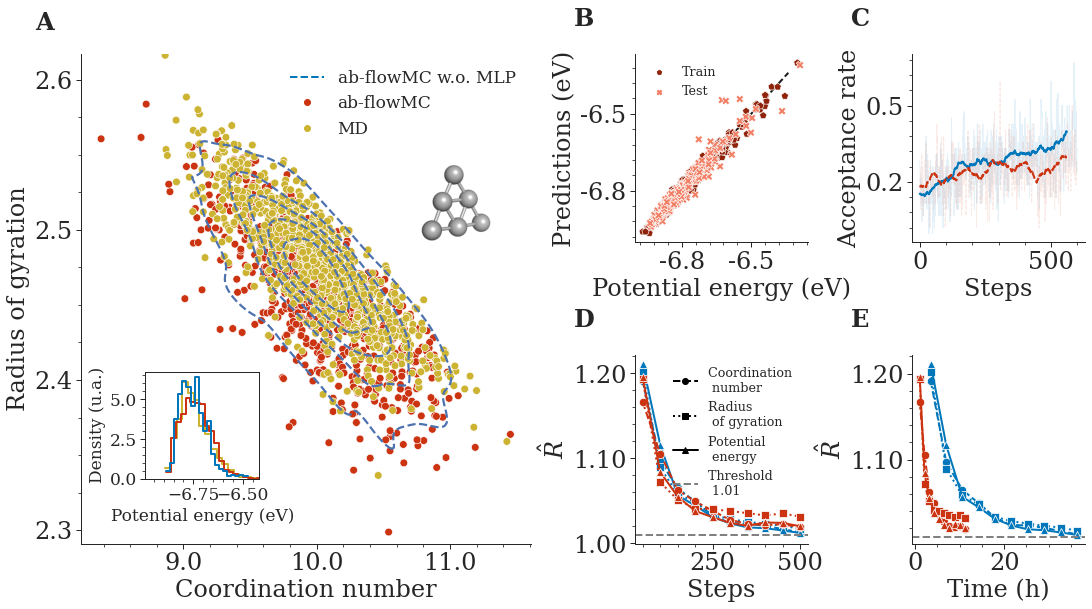

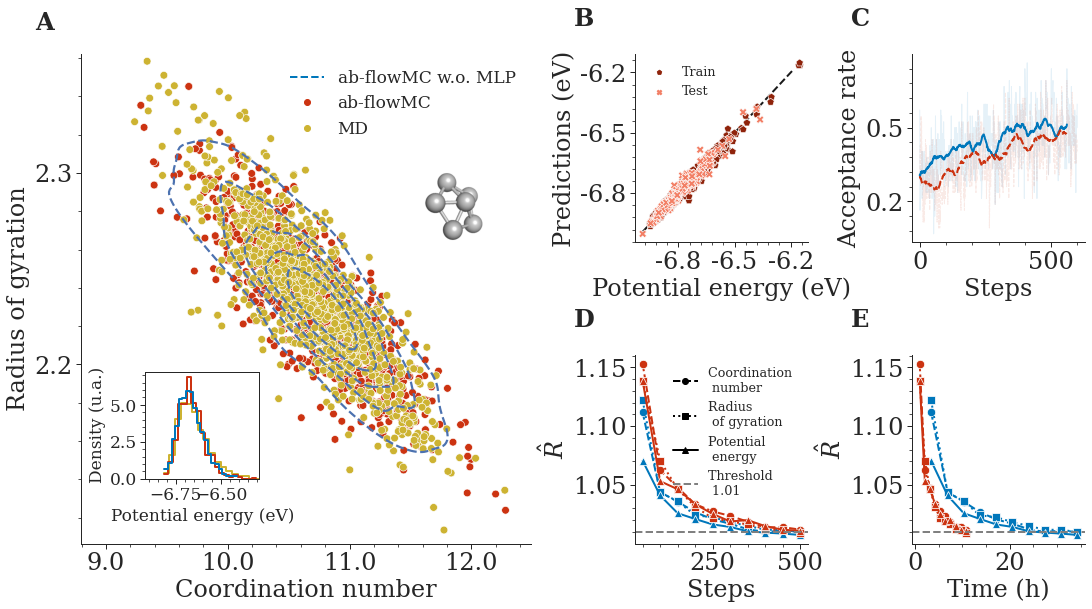

In [203]:
for i in cvs_energy_is.keys():
    set_plot_figure_1(cvs=cvs_energy_is_rand[i][['C', 'R', 'Method']],
                density_samples=cvs_energy_is_rand[i][cvs_energy_is_rand[i]['Method']==list(methods_color.keys())[0]],
                #density_samples_is[i][
                #    density_samples_is[i]['Method']==list(methods_color.keys())[1]
                #    ],
                accs=accs_is[i],
                rhat=rhats_is[i],
                energies=cvs_energy_is_rand[i][['U', 'Method']],
                np_predictions=np_predictions[i],
                isomer=i, 
                colors=methods_color)
    
    plt.savefig(path_to_save_figures+'figure_1_is{:d}.png'.format(i), 
            dpi=300, 
            facecolor='white',
            transparent=False)

# add line or fit to legend in B

# Figure 2 - ab-flowMM

In [204]:
cvs_energy_mcmc = pd.read_csv(
    project_path + '/' + data_path + '/cvs_energy_is_ab-flowMM.csv'
                )

density_samples_mcmc = pd.read_csv(
    project_path + '/' + data_path + '/density_samples_ab-flowMM.csv'    
)

isomers_mcmc = pd.read_csv(
        project_path + '/' + data_path + '/isomers_ab-flowMM.csv'    
)

time_mcmcs = pd.read_csv(
        project_path + '/' + data_path + '/time_mcmcs_ab-flowMM.csv'    
)

In [205]:
rhats_mcmc = {}

for method in ['ab-flowMM w.o. MLP', 'ab-flowMM']:
        
    cvs = cvs_energy_mcmc[ cvs_energy_mcmc['Method'] == method
                        ][['C', 'R', 'U']].to_numpy()

    cvs = cvs.reshape(2750, 20, 3)
    
    rhat = R_hat(cvs.transpose(1, 0, 2), labels=['C', 'R', 'U'])
    rhats_mcmc[method] = rhat

In [206]:
isomers = isomers_mcmc[isomers_mcmc['Method']=='ab-flowMM'][[str(i) for i in range(20)]].to_numpy()

x = np.arange(0, isomers.shape[0])
y = np.arange(0, isomers.shape[1])

z = isomers.T
horzSum = np.array([torch.unique_consecutive(torch.tensor(z[i])).shape[0] - 1 for i in range(20)])
#np.sum(z, 1)
index_sort = np.argsort(horzSum)

z = z[index_sort, :]
horzSum = horzSum[index_sort]

In [207]:
populations = pd.read_csv(
    project_path + '/' + data_path + '/populations_ab-flowMM.csv'
)

mask = [col for col in populations.columns if '500' in col]

populations = populations[mask]

In [208]:
dfs = []

cols = populations.columns.to_list()
for col in cols:
    df = pd.DataFrame(columns=['Method', 'Adaptive stages', '# DFT evaluations', 'Populations'])
    method_name = ' '.join(col.split(' ')[:-4])
    stage = 'Stage ' + col.split(' ')[-3]
    df['Populations'] = populations[col]
    df['Method'] = method_name
    df['Adaptive stages'] = stage
    if method_name == 'ab-flowMM':
        frac = [0.3, 0.2]
    else:
        frac = [1, 1]
    df['# DFT evaluations'] = int((20*50*int(col.split(' ')[-3])*frac[0] + 2750*20*frac[1])*1e-3)
    dfs.append(df)

populations_df = pd.concat(dfs, ignore_index=True)  

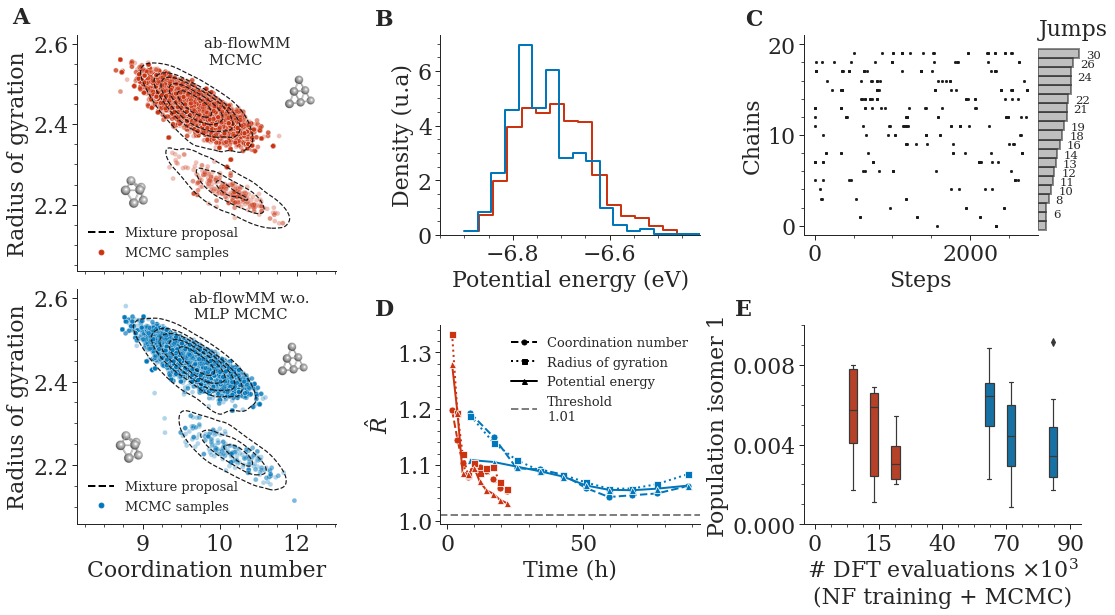

In [234]:
figsize=(6*3, 3*3)
fontsize=22
size_axes_label=22
size_tick_label=22
size_legend=13
linewidth=2
markersize=5
hspace=0.45
wspace=0.6

ncols = 4
nrows = 2

sns.set_context("paper", rc={"font.size":fontsize,
                    "axes.titlesize":fontsize,
                    "axes.labelsize":size_axes_label,
                    "xtick.labelsize":size_tick_label,
                    "ytick.labelsize":size_tick_label,
                    "legend.fontsize":size_legend,
                    })   

# -- set figure --

fig, axs = plt.subplots(ncols=ncols, 
                nrows=nrows, 
                figsize=figsize,
                gridspec_kw={'width_ratios': [1.5, 1.5, 0.75, 0.25],
                'height_ratios': [1, 1],
                'wspace': wspace,
                'hspace': hspace}
                )
 
# -- set subplots --

# -- cvs subplots --

ax1 = axs[0][0]
ax4 = axs[1][0]

axs_scatter = [ax1, ax4]

# -- energies and isomers subplots --

ax2 = axs[0][1]

ax3 = axs[0][2]
ax_small = axs[0][3]

# -- rhats and populations subplots --

ax5 = axs[1][1]

gs_ax = axs[1][2].get_gridspec()
axs[1][2].remove()
axs[1][3].remove()

ax6 = fig.add_subplot(gs_ax[1, 2:])

# -- item to subplot and delete top and right axis lines --

posx = -0.25
posy = 1.05

for n, ax in enumerate([ax1, ax2, ax3, ax5, ax6]):
    
    ax.text(posx,
    posy,
    string.ascii_uppercase[n], 
    transform=ax.transAxes, 
    weight='bold')

    ax.spines[['right', 'top']].set_visible(False)

ax4.spines[['right', 'top']].set_visible(False)
ax_small.spines[['left', 'right', 'top']].set_visible(False)

# -- sharing axis subplots --

ax4.sharex(ax1)
plt.setp(ax1.get_xticklabels(), visible=False)

ax3.sharey(ax_small)

# -- update positions --

    # -- updating cvs plot size -- 

diff = ax1.get_position().get_points()[0][1] - ax4.get_position().get_points()[1][1]

ax1.set_position(Bbox(ax1.get_position().get_points() - np.array([[0, 1], [0, 0]])*(diff/2)*0.8))
ax4.set_position(Bbox(ax4.get_position().get_points() + np.array([[0, 0], [0, 1]])*(diff/2)*0.8))

ax1.text(10.2, 2.55, 'ab-flowMM \n MCMC', fontsize=size_legend*1.15)
ax4.text(9.9, 2.55, 'ab-flowMM w.o. \n MLP MCMC', fontsize=size_legend*1.15)


    # -- updating isomers plot size --

update_position = ax3.get_position().get_points()
update_position[1][0] = ax_small.get_position().xmin*1
ax3.set_position(Bbox(update_position))

# -- plot cvs (density) --

sns.kdeplot(density_samples_mcmc[ 
    density_samples_mcmc['Method'] == 'ab-flowMM'
    ],
    x='C',
    y='R',
    color='k',
    linestyles='--',
    linewidth=linewidth,
    levels=6,
    ax=ax1,
    )

ax1.plot([],[],   
            linestyle='dashed',
            linewidth=linewidth, 
            color='black', 
            label="Mixture proposal" )[0]

ax1.plot([],[],   
            #linestyle='dotted',
            linewidth=0,
            marker='o',
            color=methods_color['ab-flowMC'], 
            label="MCMC samples" )

sns.scatterplot(
    data=cvs_energy_mcmc[ cvs_energy_mcmc['Method'] == 'ab-flowMM' ], 
    x='C', 
    y='R',
    hue='Method',
    linewidths=linewidth,
    palette=methods_color,
    ax=ax1,
    legend=False,
    alpha=0.3,
    )

ax1.legend(loc='lower left')
ax1.set_ylabel('Radius of gyration')

sns.kdeplot(density_samples_mcmc[ 
    density_samples_mcmc['Method'] == 'ab-flowMM w.o. MLP'
    ],
    x='C',
    y='R',
    color='k',
    linestyles='--',
    linewidth=linewidth,
    levels=6,
    ax=ax4
    )

ax4.plot([],[],   
            linestyle='dashed',
            linewidth=linewidth, 
            color='black', 
            label="Mixture proposal" )[0]

ax4.plot([],[],   
            #linestyle='dotted',
            linewidth=0,
            marker='o',
            color=methods_color['ab-flowMC w.o. MLP'], 
            label="MCMC samples" )

sns.scatterplot(
    data=cvs_energy_mcmc[ cvs_energy_mcmc['Method'] == 'ab-flowMM w.o. MLP' ], 
    x='C', 
    y='R',
    hue='Method', 
    linewidths=linewidth,
    palette=methods_color,
    ax=ax4,
    alpha=0.3,
    legend=False
    )

ax4.legend(loc='lower left')

ax4.set_xlabel('Coordination number')
ax4.set_ylabel('Radius of gyration')

# -- plot structure --


l, b, h, w = ax1.get_position().get_points().flatten()
for i in range(2):
    ax_mol = fig.add_axes([l*[1.5, 0.4][i], b*np.array([1.45, 1.15])[i], w*[0.25, 0.275][i], h*[0.25, 0.275][i]])
    ax_mol.set_axis_off()
    ax_mol.imshow(load_ag6_image(i))

l, b, h, w = ax4.get_position().get_points().flatten()
for i in range(2):
    ax_mol = fig.add_axes([l*[1.85, 0.8][i], b*[2.7, 1.6][i], w*[0.25, 0.275][i], h*[0.25, 0.275][i]])
    ax_mol.set_axis_off()
    ax_mol.imshow(load_ag6_image(i))


# -- plot energy --

sns.histplot(data=cvs_energy_mcmc,
            stat='density',
            x='U',
            hue='Method',
            bins=20,
            alpha=1,
            palette=methods_color,
            element='step',
            linewidth=linewidth,
            fill=False,
            ax=ax2, 
            common_bins=False, 
            common_norm=False,
            legend=False, 
            )

ax2.set_xlim(cvs_energy_mcmc['U'].min()-0.05, 
             cvs_energy_mcmc['U'].max()-0.1)

ax2.set_xlabel('Potential energy (eV)')
ax2.set_ylabel('Density (u.a)')

# -- plot rhats --

markers = ['o', 's', '^']
linestyles = ['dashed', 'dotted', '-']
labels = ['Coordination number', 'Radius of gyration', 'Potential energy']

for key in rhats_mcmc.keys():
    for i in range(rhats_mcmc[key][0].shape[-1]):
        sns.lineplot(x=time_mcmcs[key][rhats_mcmc[key][1]], 
                    #x=rhats_mcmc[key][1],
                    y=rhats_mcmc[key][0][:, i], 
                    linestyle=linestyles[i], 
                    marker=markers[i],
                    markersize=markersize*1.4,
                    linewidth=linewidth,
                    color=methods_color[key], 
                    label=rhats_mcmc[key][2][i],
                    ax=ax5,
                    legend=False)

ax5.axhline(1.01, c='grey', ls='--', 
              linewidth=linewidth)
#ax5.set_xlabel('Steps')
ax5.set_xlabel('Time (h)')
ax5.set_ylabel(r'$\hat{R}$')

# -- plot rhat legend --
        
patches = [ ax5.plot([],[], 
                           marker=markers[i], 
                           linestyle=linestyles[i], 
                           linewidth=linewidth, 
                           markersize=markersize, 
                           color='black', 
                           label="{:s}".format(labels[i]) )[0]  for i in range(len(rhats_mcmc[key][2])) ]

patches = patches + [ ax5.plot([],[],
                            linestyle='dashed', 
                            linewidth=linewidth, 
                            color='gray', 
                            label="{:s}".format('Threshold\n1.01') )[0] ]

ax5.legend(handles=patches)

# -- plot isomers --

for i in range(z.shape[0]):
    mask = z[i]==1
    x = np.arange(0, z.shape[1], 1)
    y = np.ones(z.shape[1])*i
    
    ax3.scatter(x[mask], y[mask], s=5, marker='o', c='k')

ax_small.barh(np.array(range(len(horzSum))), 
        horzSum, 
        1, 
        color='gray', 
        edgecolor='k', 
        linewidth=linewidth, 
        alpha=0.5)

ax_small.text(0.8, 21, 'Jumps')

values, indexes, counts = np.unique(horzSum, return_index=True, return_counts=True)
counts[counts == 1] = 0

for index, value, count in zip(indexes, values, counts):
    ax_small.text(value + 5, 
                index - 0.5 + count/2,
                str(int(value)), 
                fontsize=size_legend*0.9)

ax3.set_ylim(-1, len(z)+1)
  
ax3.set_xlabel('Steps')
ax3.set_ylabel('Chains')

ax_small.set_axis_off()

# -- plot populations --

order_scale = np.unique(sorted(populations_df['# DFT evaluations'].unique().tolist() + list(range(0, 100, 10))))

sns.boxplot(populations_df,
            x='# DFT evaluations',
            y='Populations',
            hue='Method',
            palette=methods_color,
            order=order_scale,
            ax=ax6,
            )

ax6.set_ylim(0, 0.01)
ax6.legend().remove()

ax6.set_ylabel('Population isomer 1')
ax6.set_xlabel(r'# DFT evaluations $\times$10$^3$' '\n' '(NF training + MCMC)')

ax6.yaxis.set_major_locator(plt.MaxNLocator(3))
ax6.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.3f'))

#ax1.yaxis.set_major_locator(plt.MaxNLocator(4))
ax1.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.1f'))

#ax4.yaxis.set_major_locator(plt.MaxNLocator(4))
ax4.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.1f'))
ax4.xaxis.set_major_locator(plt.MaxNLocator(4))
ax4.xaxis.set_major_formatter(ticker.FormatStrFormatter('%d'))

ax6.xaxis.set_major_locator(plt.MaxNLocator(5))
ax6.yaxis.set_major_locator(plt.MaxNLocator(3))

plt.savefig(path_to_save_figures+'figure_2_mixture_time.png', 
            dpi=300, 
            facecolor='white', 
            transparent=False
            )

# Figure 3 - Optical spectrum

In [210]:
opt_data = pd.read_csv(get_project_path() + '/' + data_path + '/optical_spectra.csv')

In [211]:
#opt_0K = {i: pd.read_csv(project_path + '/' + data_path + '/is{:d}_opt_spc_0K.csv'.format(i)) for i in range(2)}
#opt_md = {i: pd.read_csv(project_path + '/' + data_path + '/is{:d}_opt_spc_MD_350K.csv'.format(i)) for i in range(2)}
#opt_mcmc = {i: pd.read_csv(project_path + '/' + data_path + '/is{:d}_opt_spc_MCMC_350K.csv'.format(i)) for i in range(2)}

In [212]:
#for i in range(2):
#    opt_md[i]['means'] = opt_md[i][opt_md[i].columns[1:]].mean(axis=1)
#    opt_md[i]['stds'] = opt_md[i][opt_md[i].columns[1:]].std(axis=1)/np.sqrt(opt_md[i].shape[1])
#
#    opt_mcmc[i]['means'] = opt_mcmc[i][opt_mcmc[i].columns[1:]].mean(axis=1)
#    opt_mcmc[i]['stds'] = opt_mcmc[i][opt_mcmc[i].columns[1:]].std(axis=1)/np.sqrt(opt_mcmc[i].shape[1])

In [213]:
opt_spc_colors = dict(zip(['T=OK', 'MD', 'ab-flowMC', 'ab-flowMC w.o. MLP'],
                        ['#808080', '#cdb332', '#CC3311', 
                        '#0077BB']))

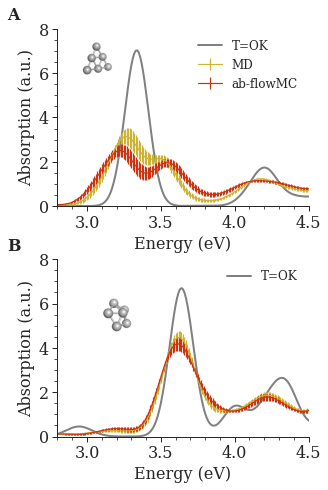

In [233]:
figsize=(4.5*1, 3.75*2)
fontsize=16
size_axes_label=16
size_tick_label=16
size_legend=12
linewidth=2
markersize=5
hspace=0.3
wspace=0.0

ncols = 1
nrows = 2

sns.set_context("paper", rc={"font.size":fontsize,
                    "axes.titlesize":fontsize,
                    "axes.labelsize":size_axes_label,
                    "xtick.labelsize":size_tick_label,
                    "ytick.labelsize":size_tick_label,
                    "legend.fontsize":size_legend,
                    })

# -- set figure --

fig, axs = plt.subplots(ncols=ncols,
                nrows=nrows,
                figsize=figsize,
                gridspec_kw={'wspace': wspace,
                            'hspace': hspace}
                            )

# -- set subplots --

ax1 = axs[0]
ax2 = axs[1]

# -- item to subplot and delete top and right axis lines --

posx = -0.2
posy = 1.05

for n, ax in enumerate([ax1, ax2]):
        
    ax.text(posx,
    posy,
    string.ascii_uppercase[n], 
    transform=ax.transAxes, 
    weight='bold')

    ax.spines[['right', 'top']].set_visible(False)

# -- plot opt spc --

n=50

from scipy.stats import t
t = t.ppf(1-0.05/2, n-1)

for i in range(2):
    
    sns.lineplot(#data=opt_data['T0K_is'+str(i)+'_dft'],
            x=opt_data['energy'],
            y=opt_data['T0K_is'+str(i)+'_dft'],
            linewidth=linewidth,
            ax=axs[i],
            color=opt_spc_colors['T=OK'],
            label='T=OK'
            )

    axs[i].errorbar(opt_data['energy'],
                    opt_data['mean_350K_is'+str(i)+'_md'],
                    yerr=t*opt_data['std_350K_is'+str(i)+'_md'],
                    color=opt_spc_colors['MD'],
                    label='MD')

    axs[i].errorbar(opt_data['energy'],
                    opt_data['mean_350K_is'+str(i)+'_mlp'],
                    yerr=t*opt_data['std_350K_is'+str(i)+'_mlp']/np.sqrt(n),
                    color=opt_spc_colors['ab-flowMC'],
                    label='ab-flowMC')


# -- set the limits of x and y axis --

ax1.set_ylabel('Absorption (a.u.)')
ax2.set_ylabel('Absorption (a.u.)')

for i in range(2):

    axs[i].set_xlabel('Energy (eV)')

    axs[i].set_xlim(2.8, 4.5)
    axs[i].set_ylim(0, 8)

ax1.legend()
#ax2.legend().remove()
#ax1.set(xlabel=None)

# -- add image isomer --

l, b, h, w = ax1.get_position().get_points().flatten()
axsmall_1 = fig.add_axes([l*1.35, b*1.35, h*0.175, w*0.175])
axsmall_1.imshow(load_ag6_image(0))
axsmall_1.set_axis_off()

l, b, h, w = ax2.get_position().get_points().flatten()
axsmall_2 = fig.add_axes([l*1.65, b*2.35, h*0.245, w*0.245])
axsmall_2.imshow(load_ag6_image(1))
axsmall_2.set_axis_off()

#ax1.set_aspect('equal')
#ax2.set_aspect('equal')

# -- sharing axis subplots --

ax2.sharex(ax1)
#plt.setp(ax1.get_xticklabels(), visible=False)

plt.savefig(path_to_save_figures+'figure_3_optical.png',
            dpi=300, 
            facecolor='white',
            transparent=False)
    

# Suplementary

#### Negative log likelihood

In [215]:
nlls_df = pd.read_csv(project_path + '/' + data_path + '/nll_ab-flowMC.csv')

In [216]:
from ase.units import kB
from scipy.stats import linregress

In [217]:
T = 350
beta = 1/(kB*T)
beta

33.15577731543145

1.0206290858659823 6.6003982261248835
1.008061692113484 6.5050070760302185
1.0561882481281275 6.668523551617096
1.0831103283107295 6.838724121384635


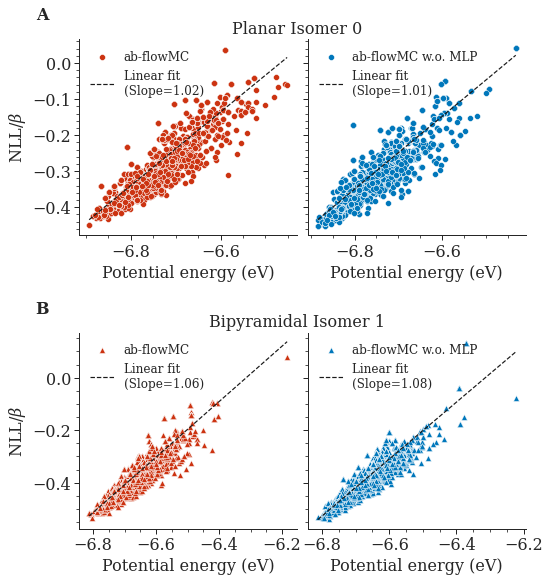

In [262]:
ncols = 2
nrows = 2

figsize=(4*ncols, 4.5*nrows)
fontsize=16
size_axes_label=16
size_tick_label=16
size_legend=12
linewidth=2
markersize=5
hspace=0.5
wspace=0.05

sns.set_context("paper", rc={"font.size":fontsize,
                    "axes.titlesize":fontsize,
                    "axes.labelsize":size_axes_label,
                    "xtick.labelsize":size_tick_label,
                    "ytick.labelsize":size_tick_label,
                    "legend.fontsize":size_legend,
                    })

# -- set figure --

fig, axs = plt.subplots(ncols=ncols,
                nrows=nrows,
                figsize=figsize,
                gridspec_kw={'wspace': wspace,
                            'hspace': hspace}
)

palettes = ['flare', 'crest']
markers = ['o', '^']

for i in [0, 1]:
    for j, method in enumerate(["ab-flowMC", "ab-flowMC w.o. MLP"]):
        df = nlls_df[nlls_df['Method'] == method]
        df['NLLS'] = nlls_df['NLLS']/beta
        df = df[df['ISOMER'] == i].iloc[-15000:17000]

        slope, intercept, r, p, se = linregress(df['US'], df['NLLS'])
        print(slope, intercept)

        y = slope*np.linspace(df['US'].min(), df['US'].max(), 100) + intercept

        #scatterplot = axs[i][j].scatter(df['US'].values[-25000:], 
        #                (df['NLLS'].values/beta)[-25000:],
        #                s=20, 
        #                #c=df['STEPS'].values, 
        #                #cmap=palettes[i],
        #                color = methods_color[method],
        #                marker=markers[j],
        #                label=method)

        sns.scatterplot(df,
        x='US',
        y='NLLS',
        color=methods_color[method],
        label=method, 
        ax = axs[i][j],
        marker=markers[i],
        legend=True,
        s=35)

        sns.lineplot(x=np.linspace(df['US'].min(), df['US'].max(), 100), 
                    y=y,
                    color='k',
                    linestyle='--',
                    ax = axs[i][j], 
                    #label='Fit',
                    legend=False)

        axs[i][j].spines[['right', 'top']].set_visible(False)

        axs[i][j].plot([], [], linestyle='--',
                color='k',
                label='Linear fit \n(Slope={:.2f})'.format(slope))


axs[1][0].set_xlabel('Potential energy (eV)')
axs[1][1].set_xlabel('Potential energy (eV)')

axs[0][0].set_xlabel('Potential energy (eV)')
axs[0][1].set_xlabel('Potential energy (eV)')

axs[0][0].set_ylabel(r'NLL/$\beta$')
axs[1][0].set_ylabel(r'NLL/$\beta$')

axs[0][0].sharey(axs[0][1])
axs[1][0].sharey(axs[1][1])
plt.setp(axs[0][1].get_yticklabels(), visible=False)
plt.setp(axs[1][1].get_yticklabels(), visible=False)
axs[0][1].set(ylabel=None)
axs[1][1].set(ylabel=None)

posx = -0.2
posy = 1.1

for n, ax in enumerate([axs[0][0], axs[1][0]]):
    
    ax.text(posx,
    posy,
    string.ascii_uppercase[n], 
    transform=ax.transAxes, 
    weight='bold')

    ax.spines[['right', 'top']].set_visible(False)


#for i, method in enumerate(['ab-flowMC', 'ab-flowMC w.o. MLP']):
#    if i==0:
#        label = method
#    else:
#        label = method.split(' ')
#        label = label[0] + ' \n ' + label[1] + ' ' + label[2]
#         
#    axs[0][i].plot([], [],
#                linewidth=5,
#                color=methods_color[method],
#                label=label)

#axs[0][0].scatter([], [], 
#                marker='o',
#                color='k',
#                s=30,
#                label='Isomer 0')
#
#axs[1][0].scatter([], [], 
#                marker='^',
#                color='k',
#                s=30,
#                label='Isomer 1')

axs[0][0].legend(loc='upper left')
axs[0][1].legend(loc='upper left')
axs[1][0].legend(loc='upper left')
axs[1][1].legend(loc='upper left')

axs[0][0].set_title('Planar Isomer 0', x=1)
axs[1][0].set_title('Bipyramidal Isomer 1', x=1)

plt.savefig(path_to_save_figures+'figure_4_nlls.png',
            dpi=300, 
            facecolor='white',
            transparent=False)

### MLP Losses

In [219]:
mlp_train_losses = pd.read_csv(project_path + '/' + data_path + '/mlp_train_losses_ab-flowMC.csv')
mlp_test_losses = pd.read_csv(project_path + '/' + data_path + '/mlp_test_losses_ab-flowMC.csv')

### MLP loss

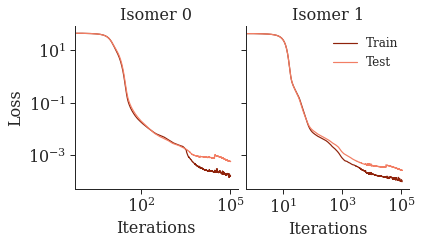

In [220]:
ncols = 2
nrows = 1

figsize=(3*ncols, 3*nrows)
fontsize=16
size_axes_label=16
size_tick_label=16
size_legend=12
linewidth=2
markersize=5
hspace=0.05
wspace=0.05

sns.set_context("paper", rc={"font.size":fontsize,
                    "axes.titlesize":fontsize,
                    "axes.labelsize":size_axes_label,
                    "xtick.labelsize":size_tick_label,
                    "ytick.labelsize":size_tick_label,
                    "legend.fontsize":size_legend,
                    })

# -- set figure --

fig, axs = plt.subplots(ncols=ncols,
                nrows=nrows,
                figsize=figsize,
                gridspec_kw={'wspace': wspace,
                            'hspace': hspace}
)

palette_predictions = dict(zip(['train', 'test'], 
                                    ['#8f230b', '#f27e64']))
for i in range(2):
    sns.lineplot(mlp_train_losses[mlp_train_losses['ISOMER'] == i]['TRAIN_LOSSES'].values,
                 ax=axs[i],
                 label='Train',
                 color=palette_predictions['train']
                )
    
    sns.lineplot(mlp_test_losses[mlp_test_losses['ISOMER'] == i]['TEST_LOSSES'].values,
                 ax=axs[i],
                 label='Test',
                color=palette_predictions['test']
                )
    
    axs[i].set_xscale('log')
    axs[i].set_yscale('log')

    axs[i].set_xlabel('Iterations')
    axs[i].spines[['right', 'top']].set_visible(False)

    axs[i].set_title('Isomer {:d}'.format(i))


axs[0].sharey(axs[1])
plt.setp(axs[1].get_yticklabels(), visible=False)
axs[1].set(ylabel=None)
axs[0].set_ylabel('Loss')
axs[0].legend()
axs[0].legend().remove()

axs[1].set_xticks([10, 1000, 100000])

plt.savefig(path_to_save_figures+'figure_4a_mlp.png',
            dpi=300, 
            facecolor='white',
            transparent=False)

### Adaptive MLP train

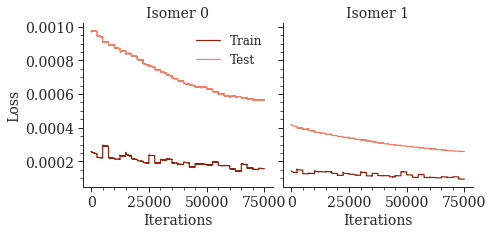

In [259]:
ncols = 2
nrows = 1

figsize=(3.5*ncols, 3*nrows)
fontsize=14
size_axes_label=14
size_tick_label=14
size_legend=12
linewidth=2
markersize=5
hspace=0.05
wspace=0.05

sns.set_context("paper", rc={"font.size":fontsize,
                    "axes.titlesize":fontsize,
                    "axes.labelsize":size_axes_label,
                    "xtick.labelsize":size_tick_label,
                    "ytick.labelsize":size_tick_label,
                    "legend.fontsize":size_legend,
                    })

# -- set figure --

fig, axs = plt.subplots(ncols=ncols,
                nrows=nrows,
                figsize=figsize,
                gridspec_kw={'wspace': wspace,
                            'hspace': hspace}
)
palette_predictions = dict(zip(['train', 'test'], 
                                    ['#8f230b', '#f27e64']))
for i in range(2):
    axs[i].plot(mlp_train_losses[mlp_train_losses['ISOMER'] == i]['TRAIN_LOSSES'][30000:].values,
                 label='Train',
                 color=palette_predictions['train']
                )
    
    axs[i].plot(mlp_test_losses[mlp_test_losses['ISOMER'] == i]['TEST_LOSSES'][30000:].values,
                 label='Test',
                 color=palette_predictions['test']
                )

    axs[i].set_xlabel('Iterations')
    axs[i].spines[['right', 'top']].set_visible(False)

    axs[i].set_title('Isomer {:d}'.format(i))


axs[0].sharey(axs[1])
plt.setp(axs[1].get_yticklabels(), visible=False)
axs[1].set(ylabel=None)
axs[0].set_ylabel('Loss')
axs[0].legend()


plt.savefig(path_to_save_figures+'figure_4b_mlps.png',
            dpi=300, 
            facecolor='white',
            transparent=False)

### Flow losses

In [222]:
flow_losses = pd.read_csv(project_path + '/' + data_path + '/flow_losses_ab-flowMC.csv')

In [223]:
df = flow_losses[flow_losses['Method'] == 'ab-flowMC w.o. MLP']

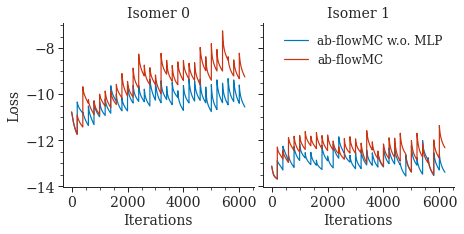

In [260]:
ncols = 2
nrows = 1

figsize=(3.5*ncols, 3*nrows)
fontsize=14
size_axes_label=14
size_tick_label=14
size_legend=12
linewidth=2
markersize=5
hspace=0.05
wspace=0.05

sns.set_context("paper", rc={"font.size":fontsize,
                    "axes.titlesize":fontsize,
                    "axes.labelsize":size_axes_label,
                    "xtick.labelsize":size_tick_label,
                    "ytick.labelsize":size_tick_label,
                    "legend.fontsize":size_legend,
                    })

# -- set figure --

fig, axs = plt.subplots(ncols=ncols,
                nrows=nrows,
                figsize=figsize,
                gridspec_kw={'wspace': wspace,
                            'hspace': hspace}
)

for i in range(2):
    sns.lineplot(flow_losses[flow_losses['ISOMER'] == i],
                 x="STEPS",
                 y="FLOW_LOSSES",
                 hue="Method",
                 palette=methods_color,
                 ax=axs[i],
                )
   
    axs[i].set_xlabel('Iterations')
    axs[i].spines[['right', 'top']].set_visible(False)
    axs[i].set_title('Isomer {:d}'.format(i))


axs[0].sharey(axs[1])
plt.setp(axs[1].get_yticklabels(), visible=False)
axs[1].set(ylabel=None)
axs[0].set_ylabel('Loss')
axs[0].legend().remove()
axs[1].legend()

plt.savefig(path_to_save_figures+'figure_5_flows.png',
            dpi=300, 
            facecolor='white',
            transparent=False)


### Acceptance rate

In [225]:
from flonacomldft.utils.plots import set_plot_sequential_data

In [226]:
accs_mcmcs = pd.read_csv(project_path + '/' + data_path + '/acceptances_ab-flowMM.csv')

In [227]:
columns = accs_mcmcs.columns
accs_cols = [col for col in columns if "500" in col]

In [228]:
accs_cols

['ab-flowMM slice 5 MD 500',
 'ab-flowMM slice 15 MD 500',
 'ab-flowMM slice 30 MD 500',
 'ab-flowMM w.o. MLP slice 5 MD 500',
 'ab-flowMM w.o. MLP slice 15 MD 500',
 'ab-flowMM w.o. MLP slice 30 MD 500']

In [229]:
colors_code = ["#ef5c3b", "#cc3311", "#85210b", "#08a5ff", "#0077bb", "#00466f"]
method_mcmcs_colors = dict(zip(accs_cols, colors_code))
method_mcmcs_colors

{'ab-flowMM slice 5 MD 500': '#ef5c3b',
 'ab-flowMM slice 15 MD 500': '#cc3311',
 'ab-flowMM slice 30 MD 500': '#85210b',
 'ab-flowMM w.o. MLP slice 5 MD 500': '#08a5ff',
 'ab-flowMM w.o. MLP slice 15 MD 500': '#0077bb',
 'ab-flowMM w.o. MLP slice 30 MD 500': '#00466f'}

ab-flowMM 5
ab-flowMM 15
ab-flowMM 30
ab-flowMM w.o. MLP 5
ab-flowMM w.o. MLP 15
ab-flowMM w.o. MLP 30


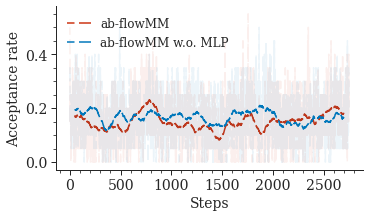

In [261]:
ncols = 1
nrows = 1

figsize=(5.5*ncols, 3*nrows)
fontsize=14
size_axes_label=14
size_tick_label=14
size_legend=12
linewidth=2
markersize=5
hspace=0.05
wspace=0.05

sns.set_context("paper", rc={"font.size":fontsize,
                    "axes.titlesize":fontsize,
                    "axes.labelsize":size_axes_label,
                    "xtick.labelsize":size_tick_label,
                    "ytick.labelsize":size_tick_label,
                    "legend.fontsize":size_legend,
                    })

# -- set figure --

fig, axs = plt.subplots(ncols=ncols,
                nrows=nrows,
                figsize=figsize,
                gridspec_kw={'wspace': wspace,
                            'hspace': hspace}
)

linestyles = {5: (0, (1, 1)), 15: (5, (10, 3)), 30: '-'}

for col in accs_cols:
        split_col = col.split(' ')
        method = ' '.join(split_col[:-4])
        slices = split_col[-3]
        print(method, slices)
        if int(slices)==15:
                set_plot_sequential_data(accs_mcmcs[col], 
                                    ax=axs,
                                    window_size=100,
                                    alpha=0.075, 
                                    linestyle=linestyles[int(slices)],
                                    #color=method_mcmcs_colors[col],
                                    color=methods_color[method],
                                    linewidth=1.5,
                                    label=method,
                                    )

    
#patches = [ axs.plot([],[], 
#                           linestyle='-',
#                           linewidth=linewidth, 
#                           color=methods_color[key], 
#            label=key)[0]  for key in ['ab-flowMM', "ab-flowMM w.o. MLP"] ] + [ axs.plot([],[], 
#                           linestyle=linestyles[i],
#                           linewidth=linewidth, 
#                           color='k', 
#            label='Adaptive stage {:d}'.format(i))[0]  for i in [5, 15, 30] ]

axs.legend()#handles=patches)

axs.set_xlabel('Steps')
axs.set_ylabel('Acceptance rate')

axs.spines[['right', 'top']].set_visible(False)

plt.savefig(path_to_save_figures+'figure_6_accs_mcmcs.png',
            dpi=300, 
            facecolor='white',
            transparent=False)
